In [27]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import ListedColormap
import matplotlib.patheffects

Board = torch.ones((8, 8))
# Board[1:2] = 2
# print(Board)
color_black_pawn= 20
color_white_pawn = 10
Board_color = 1
Board[6:7] = color_white_pawn
Board[1:2] = color_black_pawn

white_pawn = {"p1":(6,0),"p2":(6,1),"p3":(6,2),"p4":(6,3),"p5":(6,4),"p6":(6,5),"p7":(6,6),"p8":(6,7)}
black_pawn = {"p1":(1,0),"p2":(1,1),"p3":(1,2),"p4":(1,3),"p5":(1,4),"p6":(1,5),"p7":(1,6),"p8":(1,7)}

In [ ]:
"""
Variable use and their objective :

1) l_white = get_white_pawn()

    here l_white gives tuple of coordinate of random of white piece that we selected to run 
    let's say we have a piece that is being selected randomly and it is king so it will give us 
    current position tuple (2,4) from 8*8 matrix that is board.

    same goes for l_black

2) tup1 = (1,0) and tup2 = (2,0)

    here we have two tuple that will be added in the current position tuple (x,y) and the updated 
    increamented tuple will give us coordinate of moved position

    Example : pawn is at (1,3) now it can go to either one step (1,0) or two step as it is staying at starting 
    position of pawn , 
    
    if it moves one postion then moved coordinate => (1,3) + (1,0) = (2,3)

3) arguments l , opp_color, sign

    l = it is current coordinate tuple of the piece we are moving ex. (2,4)
    opp_color = numerical value of opposite piece (if black 0 , for white it is 3)
                once a piece takes a postion it turn its value to its value
                if white moved to (2,3) then value of (2,3) would be 3
                we are checking if we get opposite piece color at specific postion (left, right check)
                if one found opposite color value in that postion then it means an opposite piece is there.
                means opposite piece exist there.
    in that section.
    sign = For black is +1, for white it is -1
    


"""

In [29]:
# prev_value_black = {}
# prev_value_white = {}

def get_white_pawn():
    random_piece = random.choice(list(white_pawn.values()))
    l_white = random_piece
    print(l_white)
    return l_white
l_white = get_white_pawn()

def get_black_pawn():
    random_piece = random.choice(list(black_pawn.values()))
    l_black = random_piece
    return l_black
l_black = get_black_pawn()

# print(l)

tup1 = (1, 0)
tup2 = (2, 0)

def kill_check(l,opp_color,sign):
    left_exist = False
    right_exist = False

    t = l[0] + sign in range(8)
    u = l[1] + sign in range(8)

    if t and u:
        if Board[l[0] + sign, l[1] + sign] == opp_color:
                left_exist = True


    t = l[0] + sign in range(8)
    u = l[1] - sign in range(8)

    if t and u:
        if Board[l[0] + sign, l[1] - sign] == opp_color:
                right_exist = True
    print("kill_check")
    return left_exist , right_exist

def kill(l,sign,opp_color,dict):

    t = None

    left_exist, right_exist = kill_check(l,opp_color,sign)

    if left_exist and right_exist:
        n = torch.randint(0,2,(1,))
        if n.item() == 0:
            t = (l[0] + sign, l[1] + sign)
        else:
            t = (l[0] + sign, l[1] - sign)
        pawn_to_be_deleted = get_keys_from_value(dict, t)
        if pawn_to_be_deleted:
            del dict[pawn_to_be_deleted[0]]

    elif left_exist :
            t = (l[0] + sign, l[1] + sign)
            pawn_to_be_deleted = get_keys_from_value(dict, t)
            if pawn_to_be_deleted:
                del dict[pawn_to_be_deleted[0]]
                Board[t] = 1

    elif right_exist == True:
            t = (l[0] + sign, l[1] - sign)
            pawn_to_be_deleted = get_keys_from_value(dict, t)
            if pawn_to_be_deleted:
                del dict[pawn_to_be_deleted[0]]
                Board[t] = 1
    print("KIll")
    return t  #here t returns coordinate of place where pawn will get after killing


# Bug

def front_check(l,sign):
    t= tuple(l[i] + (sign * tup1[i]) for i in range(len(l)))
    print("front_check")
    return (Board[t] == 1).item()
    

def first_move_white(l_white):
    m = torch.randint(0, 2, (1,))
    print(m)
    if m.item() == 0:
        print("firstmovewhite")
        t_white = tuple(l_white[i] - tup1[i] for i in range(len(l_white)))
        Board[t_white] = color_white_pawn
        Board[l_white] = Board_color
        return t_white
    elif m.item() == 1:
        print("firstmovewhite")
        t_white = tuple(l_white[i] - tup2[i] for i in range(len(l_white)))
        Board[t_white] = color_white_pawn
        Board[l_white] = Board_color
        return t_white
    

def next_move_white(l_white):
    left_exist, right_exist = kill_check(l_white,color_black_pawn,-1)
    print(left_exist)
    kill_possible = left_exist or right_exist
    front_exist = front_check(l_white,-1)  # here front_exist will be True when there is no pawn ahead of it
    print(front_exist)

    if (kill_possible and front_exist):
        m = torch.randint(0, 2, (1,))
        if m.item() == 0:
            t_white = kill(l_white,-1,color_black_pawn,black_pawn)
            Board[t_white] = color_white_pawn
            Board[l_white] = Board_color
            return t_white
        else:
            t_white = tuple(l_white[i] - tup1[i] for i in range(len(l_white)))
            Board[t_white] = color_white_pawn
            Board[l_white] = Board_color
            return t_white

    elif(kill_possible):
            t_white = kill(l_white,-1,color_black_pawn,black_pawn)
            Board[t_white] = color_white_pawn
            Board[l_white] = Board_color
            return t_white
    
    elif(front_exist):
            t_white = tuple(l_white[i] - tup1[i] for i in range(len(l_white)))
            Board[t_white] = color_white_pawn
            Board[l_white] = Board_color
            return t_white
    

def first_move_black(l_black):
    m = torch.randint(0, 2, (1,))
    if m.item() == 0:
        t_black = tuple(l_black[i] + tup1[i] for i in range(len(l_black)))
        Board[t_black] = color_black_pawn
        Board[l_black] = Board_color
        return t_black

    else:
        t_black = tuple(l_black[i] + tup2[i] for i in range(len(l_black)))
        Board[t_black] = color_black_pawn
        Board[l_black] = Board_color
        return t_black



def next_move_black(l_black):
    left_exist, right_exist = kill_check(l_black,color_white_pawn,1)
    kill_possible = left_exist or right_exist
    front_exist = front_check(l_black,1)



    if (kill_possible and front_exist):
        m = torch.randint(0, 2, (1,))
        if m.item() == 0:
            t_black= kill(l_black,1,color_white_pawn,white_pawn)
            Board[t_black] = color_black_pawn
            Board[l_black] = Board_color
            return t_black

        else:
            t_black = tuple(l_black[i] + tup1[i] for i in range(len(l_black)))
            Board[t_black] = color_black_pawn
            Board[l_black] = Board_color
            return t_black


    elif(kill_possible):
            t_black = kill(l_black,1,color_white_pawn,white_pawn)
            Board[t_black] = color_black_pawn
            Board[l_black] = Board_color
            return t_black
    
    elif(front_exist):
            t_black = tuple(l_black[i] + tup1[i] for i in range(len(l_black)))
            Board[t_black] = color_black_pawn
            Board[l_black] = Board_color
            return t_black


        

def get_keys_from_value(d, target_value):
    return [k for k, v in d.items() if v == target_value]

# def Board_display():

#     board_np = Board.numpy()
#     fig, ax = plt.subplots()
#     ax.imshow(board_np)

#     # Grid
#     ax.set_xticks(torch.arange(-0.5, 8, 1), minor=True)
#     ax.set_yticks(torch.arange(-0.5, 8, 1), minor=True)
#     ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
#     ax.tick_params(which="minor", bottom=False, left=False)

#     ax.set_yticks(range(8))
#     ax.set_yticklabels([str(i) for i in range(8, 0,-1)])

#     ax.set_xticks(range(8))
#     ax.set_xticklabels(list("abcdefgh".upper()))

#     plt.show()

def Board_display():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw checkered board
    for row in range(8):
        for col in range(8):
            color = "#769656" if (row + col) % 2 == 0 else "#eeeed2"  # dark/light green squares
            ax.add_patch(plt.Rectangle((col - 0.5, row - 0.5), 1, 1, color=color))

    # Piece symbols and colors
    piece_display = {
        # White pieces
        color_white_pawn:   ("♙", "white"),
        color_white_rook:   ("♖", "white"),
        color_white_knight: ("♘", "white"),
        color_white_bishop: ("♗", "white"),
        color_white_queen:  ("♕", "white"),
        color_white_king:   ("♔", "white"),
        # Black pieces
        color_black_pawn:   ("♟", "#1a1a1a"),
        color_black_rook:   ("♜", "#1a1a1a"),
        color_black_knight: ("♞", "#1a1a1a"),
        color_black_bishop: ("♝", "#1a1a1a"),
        color_black_queen:  ("♛", "#1a1a1a"),
        color_black_king:   ("♚", "#1a1a1a"),
    }

    # Build reverse lookup: (row, col) -> piece label
    all_pieces = {}
    for label, pos in white_pawn.items():
        all_pieces[pos] = ( label, color_white_pawn)
    for label, pos in black_pawn.items():
        all_pieces[pos] = ( label, color_black_pawn)
    for label, pos in white_piece.items():
        all_pieces[pos] = (label, Board[pos[0], pos[1]].item())
    for label, pos in black_piece.items():
        all_pieces[pos] = (label, Board[pos[0], pos[1]].item())

    # Draw pieces
    for (row, col), (label, piece_color_val) in all_pieces.items():
        symbol, text_color = piece_display.get(piece_color_val, ("?", "red"))
        # Draw piece symbol
        ax.text(col, row, symbol, ha="center", va="center",
                fontsize=32, color=text_color,
                path_effects=[
                    matplotlib.patheffects.withStroke(linewidth=2, foreground="black")
                ] if text_color == "white" else [])
        # Draw label below symbol
        ax.text(col, row + 0.35, label, ha="center", va="center",
                fontsize=7, color=text_color,
                fontweight="bold",
                path_effects=[
                    matplotlib.patheffects.withStroke(linewidth=1.5, foreground="black")
                ] if text_color == "white" else [])

    # Axis labels
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(7.5, -0.5)  # flip so row 0 is at top

    ax.set_xticks(range(8))
    ax.set_xticklabels(list("ABCDEFGH"), fontsize=12)
    ax.set_yticks(range(8))
    ax.set_yticklabels([str(i) for i in range(8, 0, -1)], fontsize=12)
    
    ax.tick_params(length=0)
    ax.set_title("Chess Board", fontsize=14, fontweight="bold", pad=10)

    plt.tight_layout()
    plt.show()




(6, 4)


(6, 7)
tensor([1])
firstmovewhite


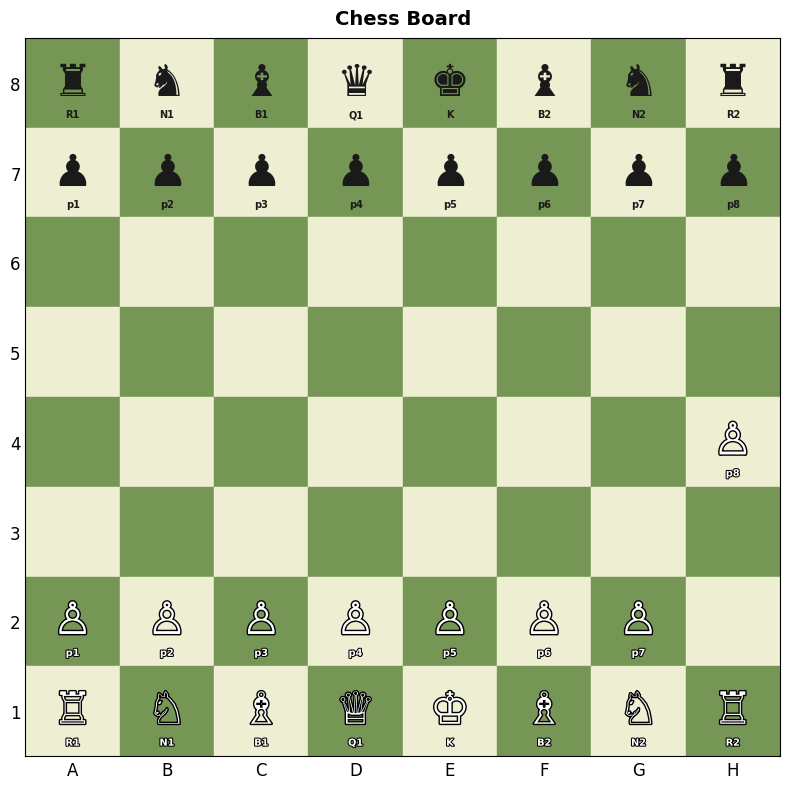

kill_check
front_check


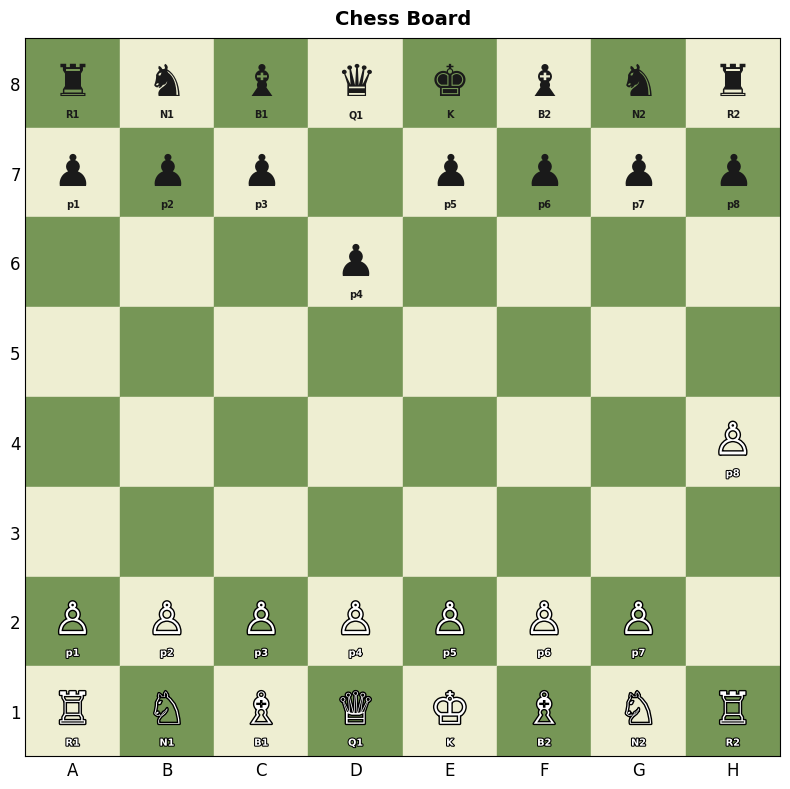

l_black is at  (1, 3)
t_black is at  (2, 3)
{'p1': (1, 0), 'p2': (1, 1), 'p3': (1, 2), 'p4': (2, 3), 'p5': (1, 4), 'p6': (1, 5), 'p7': (1, 6), 'p8': (1, 7)}
(6, 4)
kill_check
front_check
tensor([1])
firstmovewhite


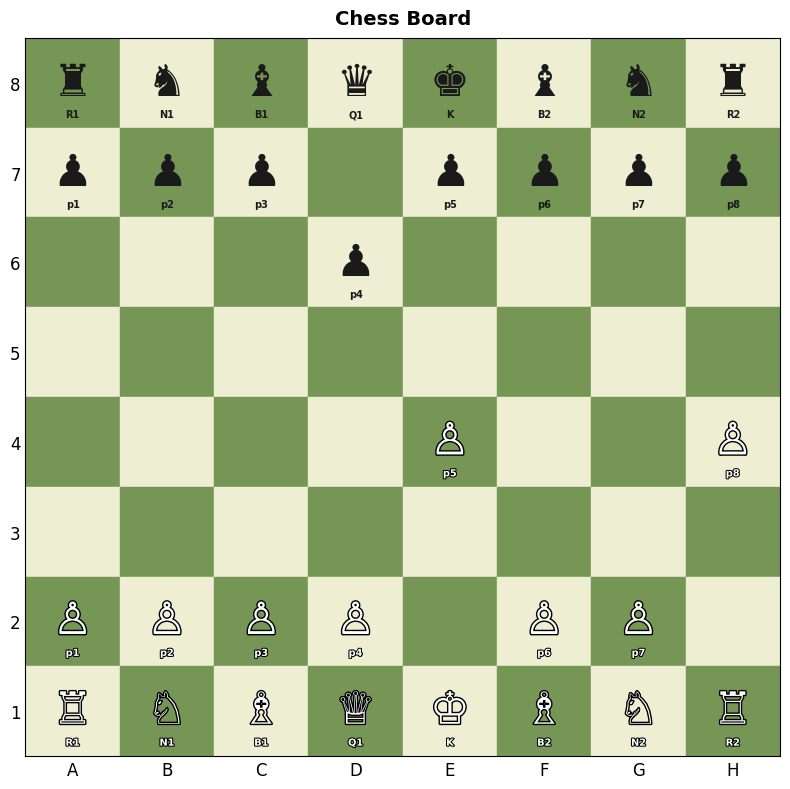

l_white is at  (6, 4)
t_white is at  (4, 4)
{'p1': (6, 0), 'p2': (6, 1), 'p3': (6, 2), 'p4': (6, 3), 'p5': (4, 4), 'p6': (6, 5), 'p7': (6, 6), 'p8': (4, 7)}
kill_check
front_check


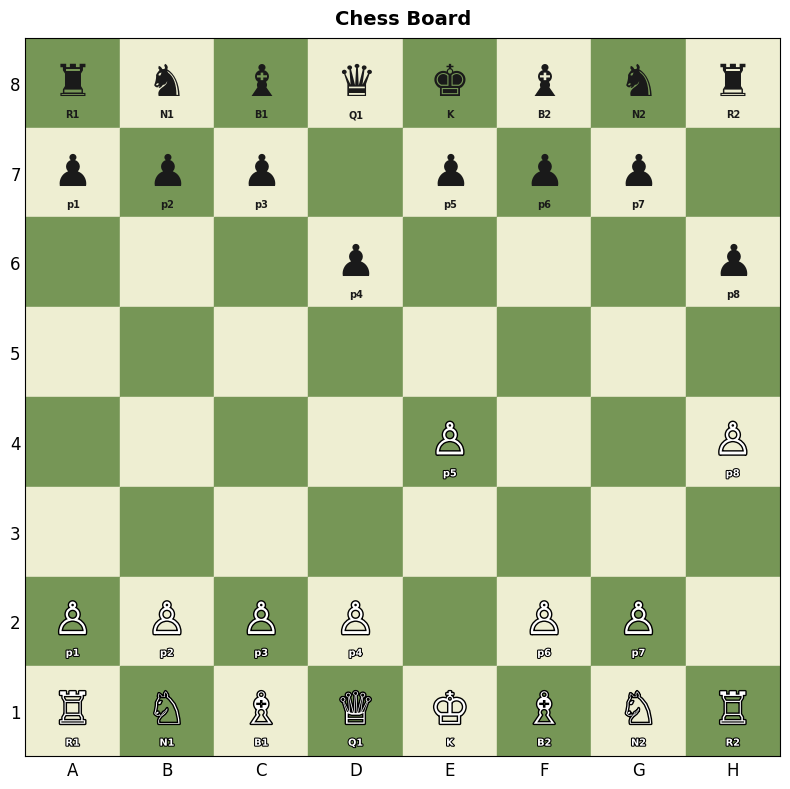

l_black is at  (1, 7)
t_black is at  (2, 7)
{'p1': (1, 0), 'p2': (1, 1), 'p3': (1, 2), 'p4': (2, 3), 'p5': (1, 4), 'p6': (1, 5), 'p7': (1, 6), 'p8': (2, 7)}
(6, 6)
kill_check
front_check
tensor([0])
firstmovewhite


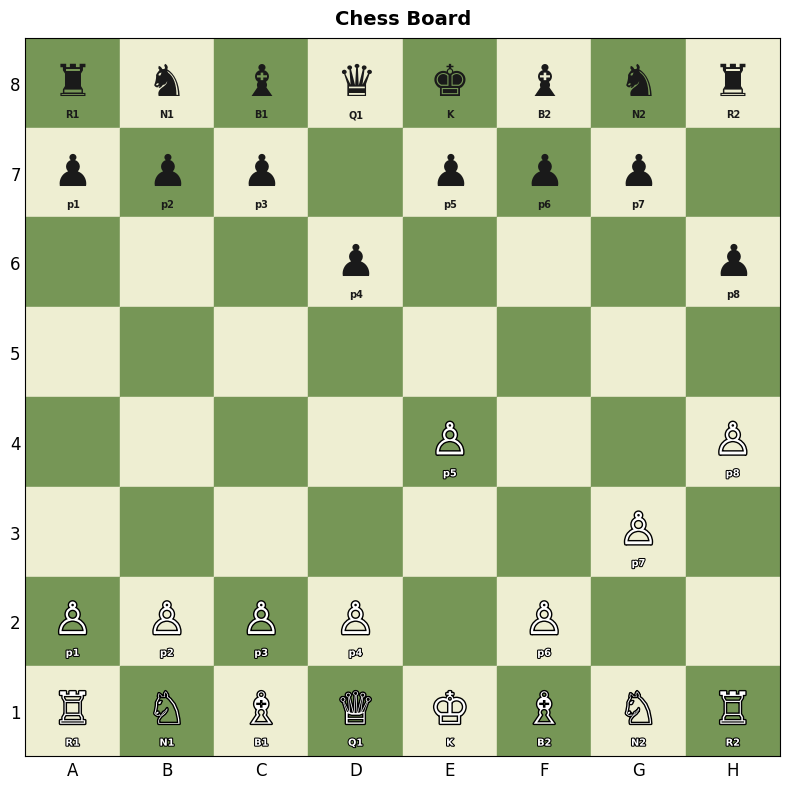

l_white is at  (6, 6)
t_white is at  (5, 6)
{'p1': (6, 0), 'p2': (6, 1), 'p3': (6, 2), 'p4': (6, 3), 'p5': (4, 4), 'p6': (6, 5), 'p7': (5, 6), 'p8': (4, 7)}
kill_check
front_check


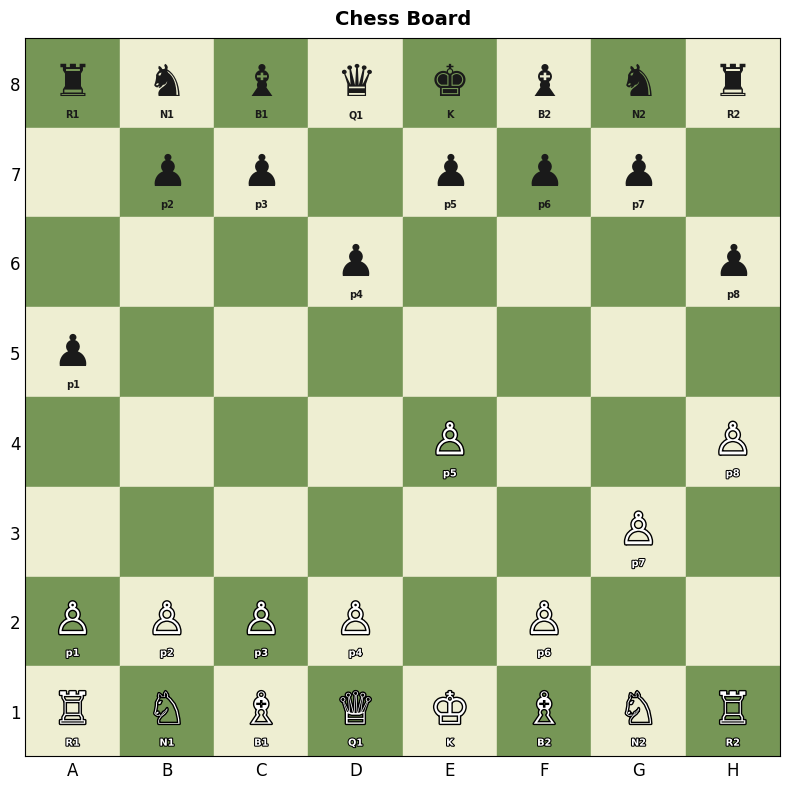

l_black is at  (1, 0)
t_black is at  (3, 0)
{'p1': (3, 0), 'p2': (1, 1), 'p3': (1, 2), 'p4': (2, 3), 'p5': (1, 4), 'p6': (1, 5), 'p7': (1, 6), 'p8': (2, 7)}
(4, 7)
kill_check
front_check
kill_check
False
front_check
True


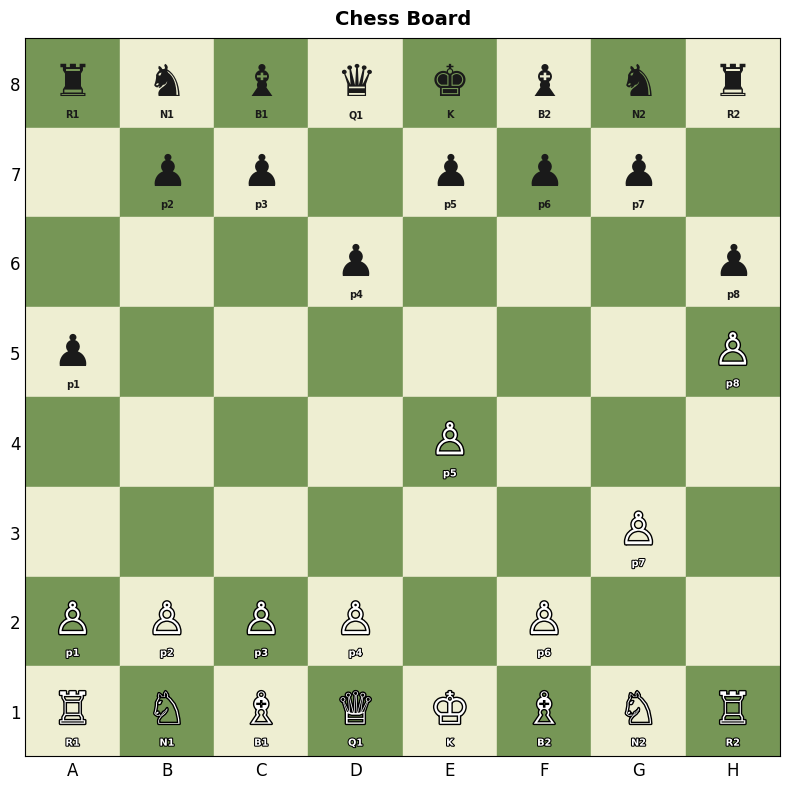

l_white is at  (4, 7)
t_white is at  (3, 7)
{'p1': (6, 0), 'p2': (6, 1), 'p3': (6, 2), 'p4': (6, 3), 'p5': (4, 4), 'p6': (6, 5), 'p7': (5, 6), 'p8': (3, 7)}
kill_check
front_check


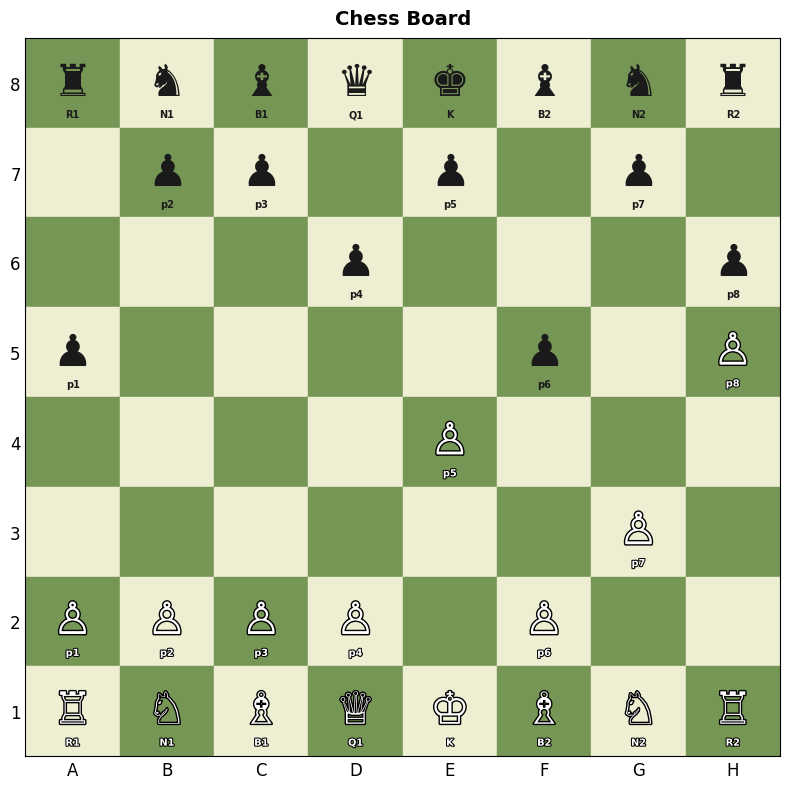

l_black is at  (1, 5)
t_black is at  (3, 5)
{'p1': (3, 0), 'p2': (1, 1), 'p3': (1, 2), 'p4': (2, 3), 'p5': (1, 4), 'p6': (3, 5), 'p7': (1, 6), 'p8': (2, 7)}


In [30]:
# Writing code for intiation of moves



l_white = get_white_pawn()

t_white = first_move_white(l_white)

key_white = get_keys_from_value(white_pawn, l_white)[0]
white_pawn[key_white] = t_white



Board_display()


for i in range(1,8):
    
    if i % 2 == 1:

        while True:
            l_black = get_black_pawn()
            if l_black is None:
                break
            left_exist, right_exist = kill_check(l_black, color_white_pawn, 1)
            kill_possible = left_exist or right_exist
            front_exist = front_check(l_black, 1)
            if (kill_possible or front_exist):
                break


        if l_black[0] == 1:
            t_black = first_move_black(l_black)
        else:
            t_black = next_move_black(l_black)

        key_black = get_keys_from_value(black_pawn, l_black)[0]
        black_pawn[key_black] = t_black

        Board_display()

        print("l_black is at ",l_black)
        print("t_black is at ",t_black)
        print(black_pawn)


    elif i % 2 == 0:
        
        while True:
            l_white = get_white_pawn()
            if l_white is None:
                break
            left_exist, right_exist = kill_check(l_white, color_black_pawn, -1)
            kill_possible = left_exist or right_exist
            front_exist = front_check(l_white, -1)
            if (kill_possible or front_exist):
                break

        if l_white[0] == 6:
            t_white = first_move_white(l_white)
        else:
            t_white = next_move_white(l_white)

        key_white = get_keys_from_value(white_pawn, l_white)[0]
        white_pawn[key_white] = t_white

        Board_display()

        print("l_white is at ",l_white)
        print("t_white is at ",t_white)

        print(white_pawn)



In [ ]:
white_piece = {"R1":(7,0),"N1":(7,1),"B1":(7,2),"Q1":(7,3),"K":(7,4),"B2":(7,5),"N2":(7,6),"R2":(7,7)}
black_piece = {"R1":(0,0),"N1":(0,1),"B1":(0,2),"Q1":(0,3),"K":(0,4),"B2":(0,5),"N2":(0,6),"R2":(0,7)}

#initial values and position of pieces on board

# thia is for rooks
Board[7, 0] = 15;  Board[7, 7] = 15
Board[0, 0] = 25;  Board[0, 7] = 25

# this is for knights
Board[7, 1] = 16;  Board[7, 6] = 16
Board[0, 1] = 26;  Board[0, 6] = 26

# this is for bishops
Board[7, 2] = 13;  Board[7, 5] = 13
Board[0, 2] = 23;  Board[0, 5] = 23

# values for queens
Board[7, 3] = 19
Board[0, 3] = 29

# value for Virat18
Board[7, 4] = 100
Board[0, 4] = 200

# Giving value separetely
color_white_rook   = 15
color_white_knight = 16
color_white_bishop = 13
color_white_queen  = 19
color_white_king   = 100

color_black_rook   = 25
color_black_knight = 26
color_black_bishop = 23
color_black_queen  = 29
color_black_king   = 200

In [ ]:

import numpy as np

# To be defined later

def king_move_check(l):  # l is l_white or l_black

    possible_move_list = np.empty((9,2), dtype=int)

    m = 0

    for i in range (-1,2):  # i equals to -1,0,+1
        for j in range(-1,2):

            x,y = l
            if i != 0 or j != 0:
                possible_move_list[m] = (x+i,y+j)
                m += 1


    return possible_move_list


print(king_move_check())

def king_kill_ckeck(l_white,l_black):
    return l_white,l_black

def king_kill(l_white,l_black):
    return l_white,l_black




TypeError: king_move_check() missing 1 required positional argument: 'l'

In [ ]:
def Queen_move_check(l_white,l_black):
    return l_white,l_black

def Queen_kill_ckeck(l_white,l_black):
    return l_white,l_black

def Queen_kill(l_white,l_black):
    return l_white,l_black

In [ ]:
def knight_move_check(l_white,l_black):
    return l_white,l_black

def knight_kill_ckeck(l_white,l_black):
    return l_white,l_black

def knight_kill(l_white,l_black):
    return l_white,l_black

In [ ]:
def bishop_move_check(l_white,l_black):
    return l_white,l_black

def bishop_kill_ckeck(l_white,l_black):
    return l_white,l_black

def bishop_kill(l_white,l_black):
    return l_white,l_black

In [ ]:
def rook_move_check(l_white,l_black):
    return l_white,l_black

def rook_kill_ckeck(l_white,l_black):
    return l_white,l_black

def rook_kill(l_white,l_black):
    return l_white,l_black